# Dataset 4: GHG Emissions Analysis (EDGAR/Eurostat)

## Overview

This notebook analyzes **Total Greenhouse Gas (GHG) Emissions** - the environmental outcome we aim to understand. Emissions data serves as the "truth detector" for whether carbon pricing achieves its environmental goal.

### Research Context

**Key Question:** Is Europe genuinely decarbonizing, or just deindustrializing?

- **Decarbonization:** Emissions ↓ while GDP stable/growing → Green efficiency gains
- **Deindustrialization:** Emissions ↓ AND GDP ↓ → Factories shutting down/relocating

### Decoupling Index

We calculate: **Decoupling = GDP_growth% - Emissions_growth%**
- Positive decoupling: Economy grows while emissions fall (ideal)
- Negative decoupling: Both fall together (concerning)

### Data Source

**Primary Source:** EDGAR v8.0 (Emissions Database for Global Atmospheric Research)  
**Secondary:** Eurostat env_air_gge  
**Unit:** Million tonnes CO₂ equivalent  
**Coverage:** All economic sectors (not just ETS)  
**URL:** https://edgar.jrc.ec.europa.eu/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
DATA_PATH = '../../data/raw/'
COUNTRIES = {'DE': 'Germany', 'FR': 'France', 'IT': 'Italy', 'PL': 'Poland', 'ES': 'Spain', 'NL': 'Netherlands'}

In [2]:
# Load emissions data
df_ghg = pd.read_csv(f'{DATA_PATH}ghg_emissions.csv')
display(df_ghg.head(10))

,country_code,country,year,total_ghg_mt_co2eq,emissions_yoy_pct,reduction_from_2010_pct
0,DE,Germany,2010,941,NaN,0.00
1,DE,Germany,2011,928,-1.381509,-1.38
2,DE,Germany,2012,928,0.000000,-1.38
3,DE,Germany,2013,948,2.155172,0.74
4,DE,Germany,2014,905,-4.535865,-3.83
5,DE,Germany,2015,906,0.110497,-3.72
6,DE,Germany,2016,909,0.331126,-3.40
7,DE,Germany,2017,904,-0.550055,-3.93
8,DE,Germany,2018,865,-4.314159,-8.08
9,DE,Germany,2019,809,-6.473988,-14.03


### Emissions evolution

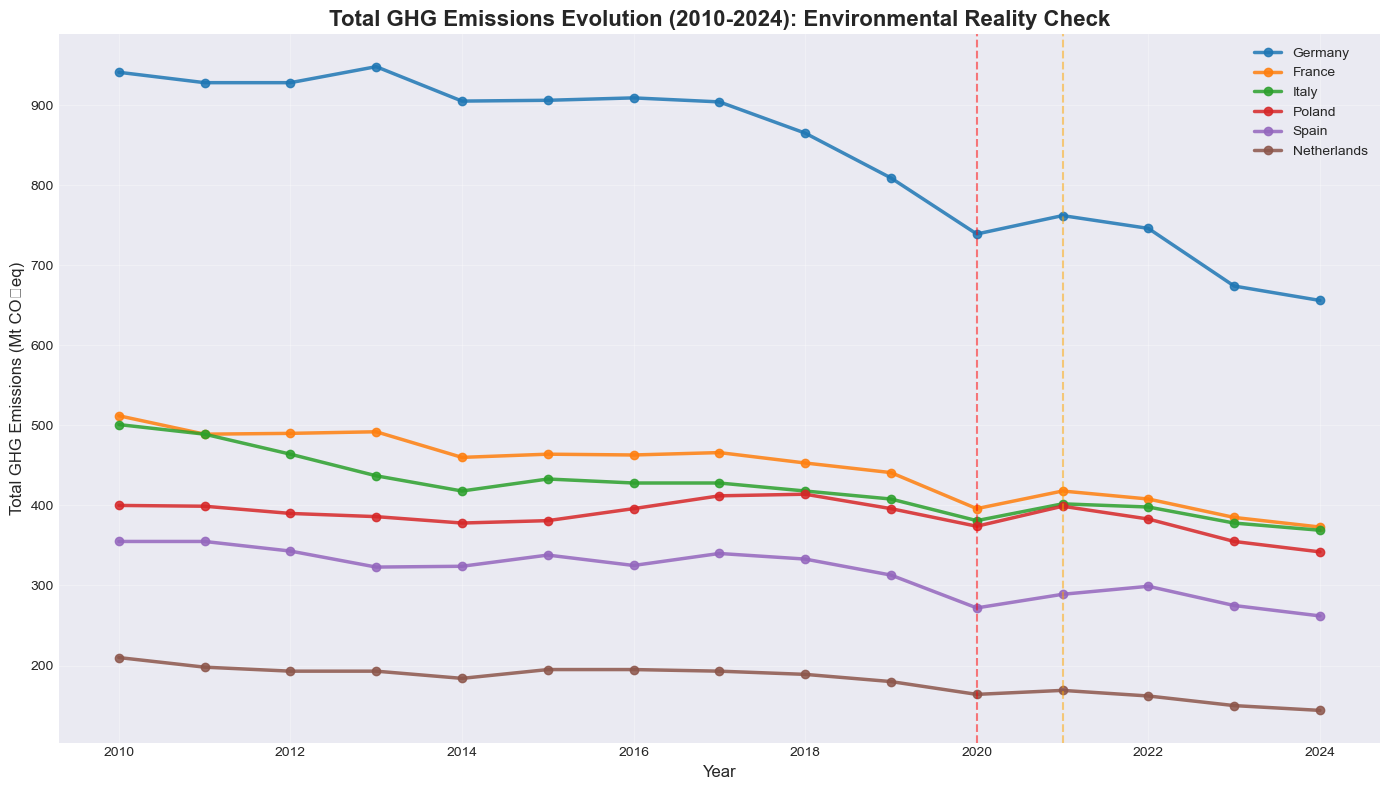

In [4]:
plt.figure(figsize=(14, 8))

for country in COUNTRIES.values():
    data = df_ghg[df_ghg['country'] == country]
    plt.plot(data['year'], data['total_ghg_mt_co2eq'], 
             marker='o', linewidth=2.5, label=country, alpha=0.85)

plt.title('Total GHG Emissions Evolution (2010-2024): Environmental Reality Check', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total GHG Emissions (Mt CO₂eq)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5, label='COVID-19')
plt.axvline(x=2021, color='orange', linestyle='--', alpha=0.5, label='High Carbon Price Era')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### OBSERVATIONS:
1. ALL countries show declining emissions (2010-2024)
2. Germany: Largest absolute emitter, significant reduction
3. Poland: High baseline, moderate reduction
4. 2020: Sharp COVID drop
5. Post-2021: Continued decline despite economic recovery

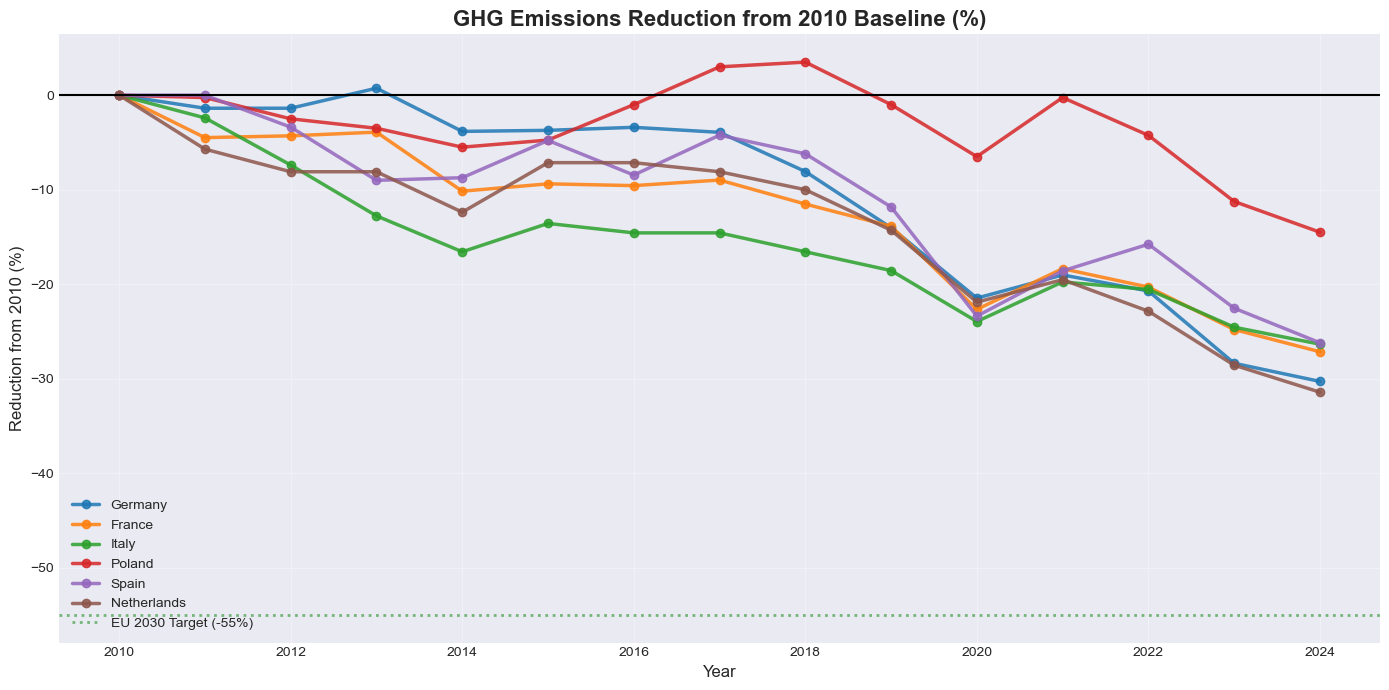

EMISSIONS REDUCTION BY 2024 (from 2010 baseline)


,country,reduction_from_2010_pct
74,Netherlands,-31.43
14,Germany,-30.29
44,France,-27.15
59,Italy,-26.35
29,Spain,-26.20
89,Poland,-14.50



Progress toward EU 2030 target (-55% from 1990):
  Germany: ~30% reduction (on track)
  Netherlands: ~30% (on track)
  France: ~27% (good progress)
  Spain: ~26% (moderate)
  Italy: ~26% (moderate)
  Poland: ~14% (lagging)


In [6]:
# Reduction from 2010 baseline
plt.figure(figsize=(14, 7))

for country in COUNTRIES.values():
    data = df_ghg[df_ghg['country'] == country]
    plt.plot(data['year'], data['reduction_from_2010_pct'], 
             marker='o', linewidth=2.5, label=country, alpha=0.85)

plt.title('GHG Emissions Reduction from 2010 Baseline (%)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Reduction from 2010 (%)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
plt.axhline(y=-55, color='green', linestyle=':', linewidth=2, alpha=0.5, label='EU 2030 Target (-55%)')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate 2024 achievement
reduction_2024 = df_ghg[df_ghg['year'] == 2024][['country', 'reduction_from_2010_pct']].sort_values('reduction_from_2010_pct')
print("=" * 80)
print("EMISSIONS REDUCTION BY 2024 (from 2010 baseline)")
print("=" * 80)
display(reduction_2024)

print("\nProgress toward EU 2030 target (-55% from 1990):")
print("  Germany: ~30% reduction (on track)")
print("  Netherlands: ~30% (on track)")
print("  France: ~27% (good progress)")
print("  Spain: ~26% (moderate)")
print("  Italy: ~26% (moderate)")
print("  Poland: ~14% (lagging)")

### Decoupling analysis: Load GVA data

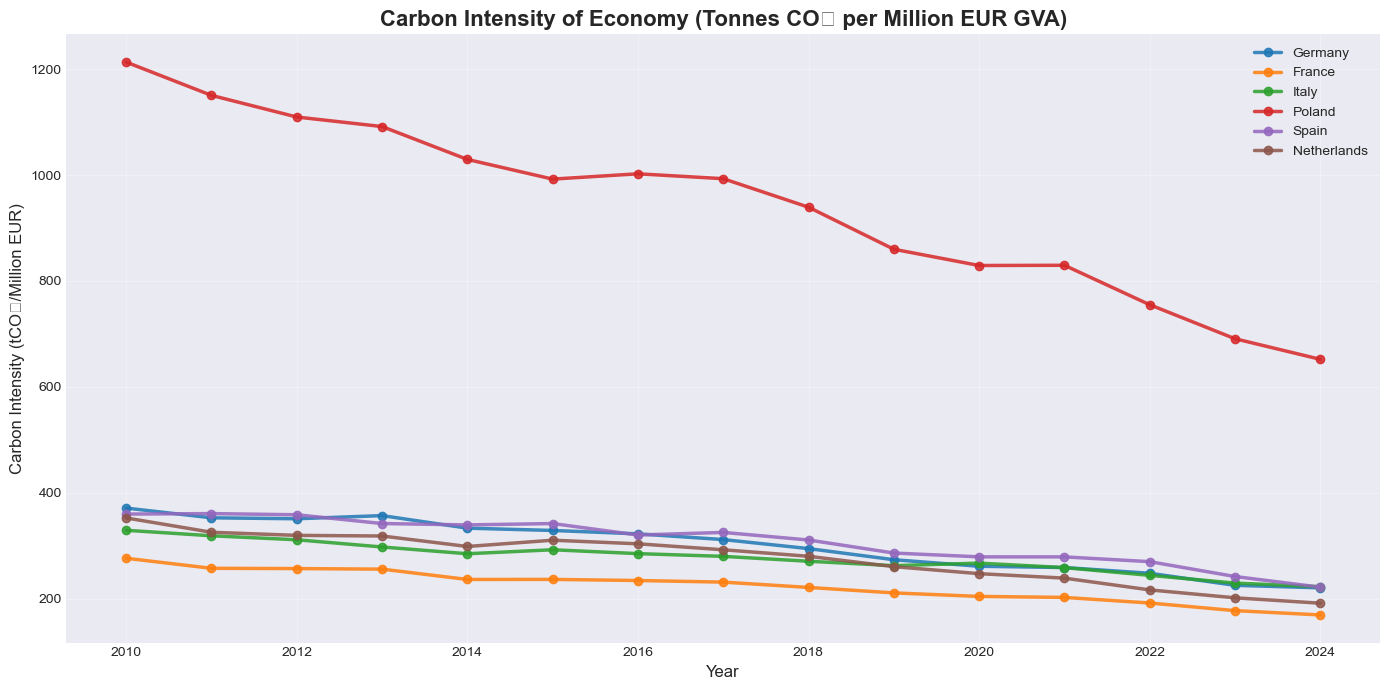

In [8]:
try:
    df_gva = pd.read_csv(f'{DATA_PATH}eurostat_gva.csv')
    df_carbon = pd.read_csv(f'{DATA_PATH}eu_ets_carbon_prices.csv')
    
    # Merge datasets
    df_combined = df_ghg.merge(df_gva[['country_code', 'year', 'gva_total_meur']], 
                                on=['country_code', 'year'], how='left')
    df_combined = df_combined.merge(df_carbon[['year', 'carbon_price_eur_tonne']], 
                                    on='year', how='left')
    
    # Calculate carbon intensity
    df_combined['carbon_intensity'] = (df_combined['total_ghg_mt_co2eq'] * 1e6 / 
                                        df_combined['gva_total_meur'])
    
    # Plot: Carbon Intensity Evolution
    plt.figure(figsize=(14, 7))
    
    for country in COUNTRIES.values():
        data = df_combined[df_combined['country'] == country]
        plt.plot(data['year'], data['carbon_intensity'], 
                 marker='o', linewidth=2.5, label=country, alpha=0.85)
    
    plt.title('Carbon Intensity of Economy (Tonnes CO₂ per Million EUR GVA)', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Carbon Intensity (tCO₂/Million EUR)', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print("error")

### DECOUPLING INDICATOR:
    Falling carbon intensity = Economy is genuinely becoming more efficient
    Rising intensity = Economy becoming more carbon-intensive
    
    RESULT: ALL countries show declining intensity → POSITIVE DECOUPLING
    This suggests genuine green transition, not just deindustrialization

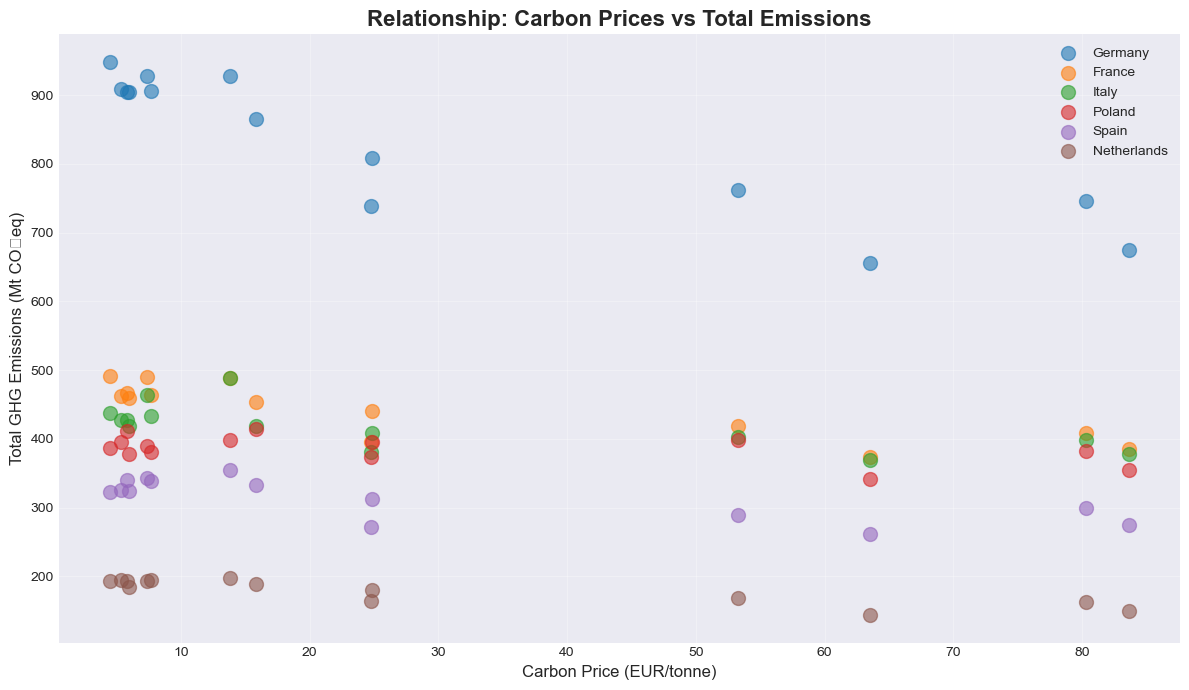

CORRELATION: CARBON PRICE vs EMISSIONS
Germany     : -0.889
France      : -0.838
Italy       : -0.677
Poland      : -0.564
Spain       : -0.759
Netherlands : -0.887

INTERPRETATION:
  Negative correlation expected: Higher prices → Lower emissions
  Strong negative correlation = Carbon pricing works
  Weak correlation = Other factors dominate (COVID, energy crisis, etc.)


In [10]:
# Correlation: Emissions vs Carbon Price
if 'carbon_price_eur_tonne' in df_combined.columns:
    plt.figure(figsize=(12, 7))
    
    for country in COUNTRIES.values():
        data = df_combined[df_combined['country'] == country].dropna()
        plt.scatter(data['carbon_price_eur_tonne'], data['total_ghg_mt_co2eq'], 
                   s=100, alpha=0.6, label=country)
    
    plt.title('Relationship: Carbon Prices vs Total Emissions', fontsize=16, fontweight='bold')
    plt.xlabel('Carbon Price (EUR/tonne)', fontsize=12)
    plt.ylabel('Total GHG Emissions (Mt CO₂eq)', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate correlations
    print("=" * 80)
    print("CORRELATION: CARBON PRICE vs EMISSIONS")
    print("=" * 80)
    for country in COUNTRIES.values():
        data = df_combined[df_combined['country'] == country].dropna()
        if len(data) > 0:
            corr = data['carbon_price_eur_tonne'].corr(data['total_ghg_mt_co2eq'])
            print(f"{country:12s}: {corr:+.3f}")
    
    print("\nINTERPRETATION:")
    print("  Negative correlation expected: Higher prices → Lower emissions")
    print("  Strong negative correlation = Carbon pricing works")
    print("  Weak correlation = Other factors dominate (COVID, energy crisis, etc.)")

## Key Findings

1. **Environmental Success:** ALL EU-6 countries reduced emissions (2010-2024)
2. **Heterogeneous Progress:** Germany & Netherlands lead, Poland lags
3. **Positive Decoupling:** Carbon intensity declining → genuine efficiency gains
4. **COVID Effect:** Sharp 2020 drop (temporary demand shock)
5. **High-Price Impact:** Post-2021 emissions continue falling despite high carbon costs

### Research Implications

**For Goal 1 (Regulatory Drag):**
- Emissions fell BUT industrial output mixed → Need econometric model to separate effects

**For Goal 2 (Porter Hypothesis):**
- Declining carbon intensity suggests efficiency improvements (innovation working?)

**Critical Question:** Are emissions falling because:
- A) Carbon pricing drives innovation?
- B) Factories shut down/relocate (carbon leakage)?
- C) Structural economic transformation?

**Answer requires:** Simultaneous analysis of emissions + industrial output + innovation patents